# 7115 Portfolio IMU Notebook

## Initial Step
After completing necessary reading and training with the lab technician, I started with my first test with the Vicon Blue trident IMU. For my first trial, I used only an IMU on the thigh and the shank, and created a python script to analyze the resulting CSV file of output in Capture U. 

In [ ]:

from scipy.spatial.transform import Rotation as R

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df=pd.read_csv(r"Assets/Walking-1_TS-03155_2026-02-20-12-10-14_aligned.csv")
df2=pd.read_csv(r"Assets/Walking-1_TS-03379_2026-02-20-12-10-14_aligned.csv")


shank= df[['qx','qy','qz','qr']].values
thigh= df2[['qx','qy','qz','qr']].values

min_len = min(len(thigh), len(shank))

thigh = thigh[:min_len]
shank = shank[:min_len]

r1=R.from_quat(thigh)
r2=R.from_quat(shank)

static_frames= 500

r_thigh_static=r1[:static_frames]
r_shank_static=r2[:static_frames]

r_offset=(r_thigh_static.inv() * r_shank_static).mean()

r_knee=r1.inv() * r2
r_knee_corrected=r_knee * r_offset.inv()

euler_knee=r_knee_corrected.as_euler('xyz', degrees=True)
plt.plot(euler_knee[:,0], label='X-axis')
plt.plot(euler_knee[:,1], label='Y-axis')
plt.plot(euler_knee[:,2], label='Z-axis')
plt.legend()

plt.show()


### What I learned:
- Make Sure you note which number IMU corresponds to which segment to properly label the
data frames when they are loaded into python.

- Time synchronised does not necessarily mean length will be the same. Have to trim to the
length of the shortest file with min(len(seg1),len(seg2)).

- scipy.spatial.transform Rotation allows for conversion of quat to rotation matrix
as long as quats are in format [x y z w] where x,y and z are sensor axes and w is a scalar.

- The participant needs to stand still before motion to establish a static period.
The static period is used to create an offset which informs the relative orientations
of the sensors when joint angle is neutral (such as standing).

- Uncorrected joint angle is computed by multiplying the inverse of the proximal joint's
rotation matrix by the distal joint's rotation matrix.  Using the inverse "wipes" the
global frames contribution, resulting in relative rotation.

- This uncorrected joint angle is than multiplied by the previously calculated offset
in order to get the corrected joint angle relative to standing (neutral).

- The rotation matrix can now be converted to euler rotations using a specified order
of rotations to return joint angles.

### Issues I encountered:
- Based on my understanding of what the sagittal plane knee joint curve should look like during normal gait, the z axis appears to be flexion and extension. Why is this?
- The sensors axes are determining dominant actions. The sensor is aligned such that x is
along the long axis of the segment, y in the direction of walking, and z orthogonal to these
completing the right hand rule.

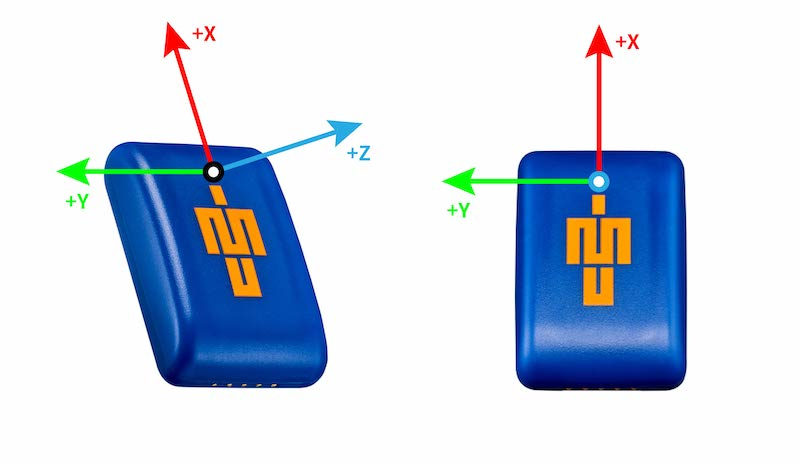

### Why do X and Y look strange?
-  Appears to be  drifitng of the x axis (not determined to be knee joint rotation) to larger negative values, and  increasing y axis magnitude  over the course of the trial. Appears to be
suggestive of potential skin artefact or crosstalk. I intend to speak with someone familiar
with these issues about why the graph looks like this.

### Whats next:
- I understand the basis behind IMU calculation, particularily reading in data, extracting
Quats, and using them in calcualation. I understan that the basis of calculations relies on
calculating offset before movement using the inverse of the proximal segment multiplied
by the distal segment while static. Than after this, getting the uncorrected knee joint angle
and using the offset to correct it. I see how this could be done in a longer script spanning
multiple joints, and feel I am ready to move onto more full body movements.

## Functional movements
For the functional movements I had placed IMUs on a participants pelvis, thighs, shank, and feet. I had the participant first complete a trial where they flexed each knee three times, than abducted each leg three times. In a separate trial I than had them complete 2 body weight squats. In a final trial I had them complete one lunge on each leg. During this final trial I had a sensor drop out, and was not able to get a full data set.

I than used the same general idea I learned to calculate knee joint angle during walking, but applied it to all the lower body joints across both the functional movements and squatting trials.






In [ ]:


data_dir = Path('Assets')



def load_data():
    trials={}
    for file in data_dir.rglob(r"*.csv"):

        parts= file.stem.split('_') #sample file name walking_L_thigh
        if len(parts)==2:#axial segments
            condition, seg= parts [0],parts[1]
            side='none'
        elif len(parts)==3: #appendicular segments
            condition, side, seg= parts [0],parts[1], parts[2]
        else:
            #print(f"Skipping unexpected filename: {file.name}") #* Quality control check
            continue


        meta_data= pd.read_csv(file,low_memory=False)

        quat_cols = ['qx', 'qy', 'qz', 'qr']
        if not all(col in meta_data.columns for col in quat_cols):
            #print(f"Skipping {file.name}: missing quaternion columns") #* Quality control check
            continue

        quats = meta_data[quat_cols]

        trials.setdefault(condition, {}).setdefault(seg, {})[side] = quats

    return trials
trials=load_data()
#%% Joint function
def calculate_joint_angles(trials, condition, proximal, distal, static_frames=500):
    prox_side, prox_seg = proximal.split('/')
    dist_side, dist_seg = distal.split('/')

    q_prox = trials[condition][prox_seg][prox_side][['qx', 'qy', 'qz', 'qr']].values
    q_dist = trials[condition][dist_seg][dist_side][['qx', 'qy', 'qz', 'qr']].values

    # trim to same length
    min_len = min(len(q_prox), len(q_dist))
    q_prox = q_prox[:min_len]
    q_dist = q_dist[:min_len]

    r_prox = R.from_quat(q_prox)
    r_dist = R.from_quat(q_dist)

    # static offset correction
    r_offset = (r_prox[:static_frames].inv() * r_dist[:static_frames]).mean()

    # joint angle
    r_joint = r_prox.inv() * r_dist
    r_joint_corrected = r_joint * r_offset.inv()

    euler = r_joint_corrected.as_euler('xyz', degrees=True)

    return euler

joints = { #preallocate proximal and distal segments for each joint
    'left_knee':  ('L/thigh',  'L/shank'),
    'right_knee': ('R/thigh', 'R/shank'),
    'left_hip':   ('none/pelvis', 'L/thigh'),
    'right_hip':  ('none/pelvis', 'R/thigh'),
    'left_ankle': ('L/shank',  'L/foot'),
    'right_ankle':('R/shank', 'R/foot'),
}

conditions= ['squat', 'functional']

results = {}

for condition in conditions:
    results[condition]={}
    for joint_name, (proximal, distal) in joints.items():
        try:
            results[condition][joint_name] = calculate_joint_angles(
                trials, condition, proximal, distal
                )
        except KeyError:
            #print(f"missing data for {condition}-{joint_name},skipping") #* Quality control check 
            continue

One error I found here was that the flexion signs were flipped on the right side, meaning that flexion was being displayed as negative on the plots. This is because the sensor axis orientation does not always align with anatomical conventions, specifically when placing on the right vs left side due to the right hand rule, and the sagital planes facing opposite of eachother in this plane. 

As a result I added some code at the end of the pipeline to correct this by flipping the sign in the dataframe so that flexion is displayed as positive on the plots. 





In [ ]:
results['functional']['right_knee'][:,2] *= -1 #flip sign for positive flexion
results['squat']['right_knee'][:,2] *= -1


I than plotted each trial, specifically the knee flexion angles and hip ab/adduction in the functional movement trial, and the knee flexion angles in the squatting trial.



In [ ]:
plt.plot(results['squat']['right_knee'][:,2], label='right knee flexion(flex+)')
plt.plot(results['squat']['left_knee'][:,2],label= 'left knee flexion(flex+)')
plt.legend()
plt.show()
plt.close()
plt.plot(results['functional']['right_knee'][:,2], label='right Knee flexion(flex+)')
plt.plot(results['functional']['left_knee'][:,2], label= 'left knee flexion(flex+)')
plt.plot(results['functional']['left_hip'][:,1], label='left hip abduction(abd+)')
plt.plot(results['functional']['right_hip'][:,1],label='right hip abduction(abd+)')
plt.legend()
plt.show()


## What I learned:
- While knee flexion was tracked very well across both trials, hip ab/adduction was not, and based on the walking test and literature,
rotation was not included. One issue that I had was poor securing of the pelvis imu, and knowing that the pelvis is needed to determine
the hip joint, this should probably be attached securely. For the next trials I colect I want to focus on making the data as accurate as
possible.

## Next step
- I will collect data from more obscure movements, focusing on accuracy of collection by limiting error from sensor placement. In addition, I will test the pipeline I created by simply adding conditions to the conditions variable and testing whether the script completes full accurate
analysis by comparing completed movements to the curves.

## More obscure movements
After basic squatting and functional movements, I wanted to test the ability to expand my code pipeline to include more obscure movements. As such I adjusted necessary sections of the pipeline to include these obscure movements. Because of the predefined load_data function and calculate_joint_angle functions all I needed to do was correctly format the files such as : 
- jj_L_foot.csv for the left foot of a jumping jack movement trial
- karate_R_thigh.csv for the right thigh of a karate kick movement
- etc

and add the name of the trial to the conditions list for inclusion in the for loop which populates the results dictionary. 




In [ ]:
conditions= ['squat', 'functional','karate', 'sts', 'shoe']



for condition in conditions:
    results[condition]={}
    for joint_name, (proximal, distal) in joints.items():
        try:
            results[condition][joint_name] = calculate_joint_angles(
                trials, condition, proximal, distal
                )
        except KeyError:
            #print(f"missing data for {condition}-{joint_name},skipping") #* Quality control check 
            continue

results['karate']['right_knee'][:,2] *= -1
results['sts']['right_knee'][:,2] *= -1
results['shoe']['right_knee'][:,2] *= -1

plt.plot(results['karate']['right_knee'][:,2], label='right Knee flexion(flex+)')
plt.plot(results['karate']['left_knee'][:,2], label= 'left knee flexion(flex+)')
plt.plot(results['karate']['left_hip'][:,1], label='left hip abduction(abd+)')
plt.plot(results['karate']['right_hip'][:,1],label='right hip abduction(abd+)')
plt.title("Karate Kicks")
plt.legend()
plt.show()


plt.plot(results['sts']['right_knee'][:,2], label='right Knee flexion(flex+)')
plt.plot(results['sts']['left_knee'][:,2], label= 'left knee flexion(flex+)')
plt.plot(results['sts']['left_hip'][:,1], label='left hip abduction(abd+)')
plt.plot(results['sts']['right_hip'][:,1],label='right hip abduction(abd+)')
plt.title("Sit to Stand")
plt.legend()
plt.show()

plt.plot(results['shoe']['right_knee'][:,2], label='right Knee flexion(flex+)')
plt.plot(results['shoe']['left_knee'][:,2], label= 'left knee flexion(flex+)')
plt.plot(results['shoe']['left_hip'][:,1], label='left hip abduction(abd+)')
plt.plot(results['shoe']['right_hip'][:,1],label='right hip abduction(abd+)')
plt.title("Tying shoe and sitting down")
plt.legend()
plt.show()



## Reflection
Each movement appears to accurately reflect what would be going on at the hip and knee joints. For example during the karate kick the right leg is lifted to kick out to the side, requiring flexion of the knee to than kick out resulting in the flexion spike and extension,paired with hip abduction as the leg is lifted to the side. This is mirrored when the other leg kicks. Analysis of curves for the other obscure movements followed a similar, justifiable portrayal of the real life movement. Therefore, the core pipeline appears usable for any movement trial, provided the movement type as it will appear when the stem of the filename is split is included in the conditions list when the for loop is run. 

## Next Step
The next step now that I understand how to complete the inverse kinematics myself is to use a software to compare joint angles from a marker based model to joint angles obtained from imu inverse kinematics. 

## Using Opensim to compare time synchronized IMU and marker inverse kinematics joint angles

Now that I understand how IMU joint angle is calculated, my next step was to use time synchronized data from a simultaneous marker and imu data collection, and feeding both into an opensim inverse kinematics tool to compare the joint angles. After configuring the imu placer tool and running the imu kinematics tool, I used a static trial to scale a generic model in opensim, and ran the opensim inverse kinematics tool. After converting both of these inverse kinematics outputs to csv files, I can than load them into python and plot a few joints on the same plot to compare outputs. 

In [ ]:
imu_df= pd.read_csv(r"Assets/imu_ik.csv", skiprows=6, header=0) #skip metadata headers
marker_df= pd.read_csv(r"Assets/marker_ik.csv",skiprows=10, header=0)

start_time= 15.468
end_time= 17.772
imu_trimmed = imu_df[(imu_df['time'] >= start_time) & (imu_df['time'] <= end_time)] #time match with marker section
plt.plot(imu_trimmed['time'], imu_trimmed['knee_angle_r'],label="imu knee")
plt.plot(marker_df['time'], marker_df['knee_angle_r'], label= "marker knee")
plt.legend()




The knee, while varying in magnitude, shows a very similar waveform. This is seen as well in the ankle. 

In [ ]:

plt.plot(imu_trimmed['time'],imu_trimmed['ankle_angle_r'], label='imu ankle')
plt.plot(marker_df['time'],marker_df["ankle_angle_r"], label= 'marker ankle')
plt.legend()


# Reflection
While the marker and imu joint angles return differing magnitudes, which could be for a number of reasons including sensor/marker placement, skin artefact, or other sensor issues, the waveform appears to be quite consistent suggesting that imu is reliably tracking the same relative joint motion as the markers. 